In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from LLS import LLS

In [2]:
data = pd.read_csv('abalone.csv')
data.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


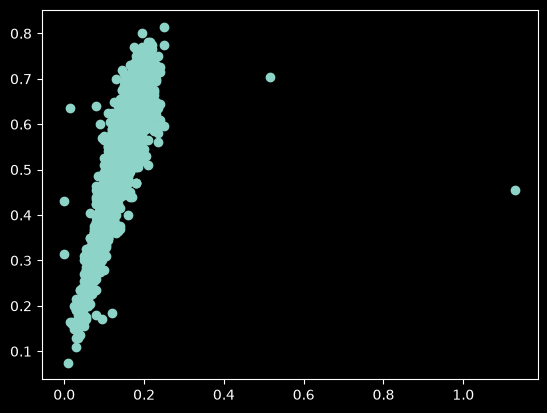

In [3]:
plt.scatter(data["Height"], data["Length"])
plt.show()

we can find 2 data column for regression


In [4]:
data["Sex"] = data["Sex"].replace(["M", "F", "I"], [0, 1, 2])

In [5]:
data.corr()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Sex,1.000000,-0.448765,-0.458245,-0.417928,-0.461238,-0.440927,-0.454658,-0.445549,-0.351822
Length,-0.448765,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,-0.458245,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,-0.417928,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole weight,-0.461238,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked weight,-0.440927,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera weight,-0.454658,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell weight,-0.445549,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,-0.351822,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


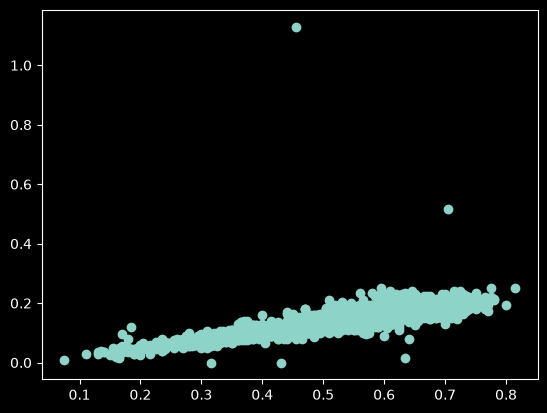

In [6]:
plt.scatter(data["Length"], data["Height"])
plt.show()

In [7]:
X = np.array(data[["Length"]])
Y = np.array(data[["Height"]])
print(X.shape)
print(Y.shape)

(4177, 1)
(4177, 1)


In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y)

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(3132, 1)
(3132, 1)
(1045, 1)
(1045, 1)


In [9]:
lls = LLS()
w = lls.fit(X_train, Y_train)
Y_pred = lls.predict(X_test)

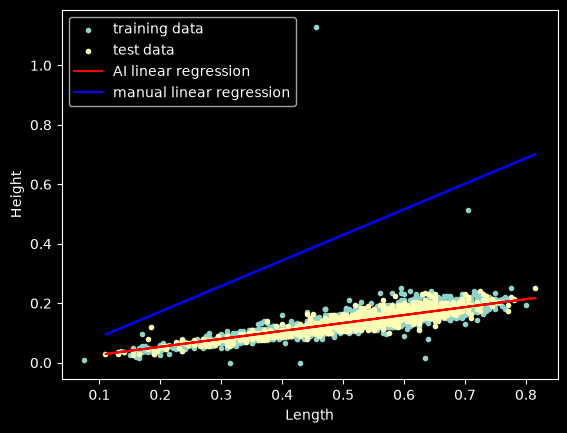

In [10]:
plt.scatter(X_train, Y_train, marker=".")
plt.scatter(X_test, Y_test, marker=".")
plt.plot(X_test, Y_pred, color="red")
plt.plot(X_test, 0.86 * X_test, color="blue")
plt.xlabel("Length")
plt.ylabel("Height")
plt.legend(["training data","test data","AI linear regression",
           "manual linear regression"],loc="upper left")
plt.show()

In [11]:
lls.evaluate(X_test, Y_test,"mae")

np.float64(0.012669980862268889)